In [1]:
import pandas as pd
import os
from IPython.display import display

# 1. ruta del archivo
file_path = os.path.join('..', 'data', 'Dataset_Listo_Para_ML.xlsx')

# 2. Carga de datos
df = pd.read_excel(file_path, engine='openpyxl')


display(df.head(10)) 

,AÑO,REGION,SECTOR,SEXO,OCUPACION,TIPO_ACCIDENTE,SEVERIDAD
0,2023,LIMA METROPOLITANA,SERVICIOS COMUNITARIOS Y SOCIALES,MASCULINO,EMPLEADO,CAÍDA AL MISMO NIVEL,1
1,2023,LIMA METROPOLITANA,INMOBILIARIA Y ALQUILERES,FEMENINO,EMPLEADO,CAÍDA AL MISMO NIVEL,2
2,2023,LIMA METROPOLITANA,ADMINISTRACIÓN PÚBLICA,MASCULINO,EMPLEADO,SOBREESFUERZO ERGONÓMICO,1
3,2024,LIMA METROPOLITANA,INDUSTRIAS MANUFACTURERAS,MASCULINO,JEFE DE PLANTA,ATRAPAMIENTO POR MÁQUINA,3
4,2023,LIMA METROPOLITANA,CONSTRUCCIÓN,MASCULINO,EMPLEADO,SOBREESFUERZO ERGONÓMICO,1
5,2023,LIMA METROPOLITANA,INDUSTRIAS MANUFACTURERAS,MASCULINO,TÉCNICO,ATRAPAMIENTO POR MÁQUINA,3
6,2023,LIMA METROPOLITANA,INDUSTRIAS MANUFACTURERAS,MASCULINO,EMPLEADO,CAÍDA AL MISMO NIVEL,2
7,2023,LIMA METROPOLITANA,COMERCIO Y REPARACIÓN AUTOMOTRIZ,MASCULINO,TÉCNICO,CONTACTO CON SUSTANCIA QUÍMICA,3
8,2023,LIMA METROPOLITANA,COMERCIO Y REPARACIÓN AUTOMOTRIZ,MASCULINO,OPERARIO,SOBREESFUERZO ERGONÓMICO,1
9,2023,LIMA METROPOLITANA,INMOBILIARIA Y ALQUILERES,FEMENINO,OPERARIO,CAÍDA AL MISMO NIVEL,2


In [2]:
from IPython.display import display

# 1. Tu limpieza de datos perfecta
df['SECTOR'] = df['SECTOR'].str.strip().str.upper()
df['TIPO_ACCIDENTE'] = df['TIPO_ACCIDENTE'].str.strip().str.upper()

df['SECTOR'] = df['SECTOR'].replace(
    'INTERMEDIACIÎ FINANCIERA',
    'INTERMEDIACIÓN FINANCIERA'
)
df['TIPO_ACCIDENTE'] = df['TIPO_ACCIDENTE'].replace(
    'CHOQUE O GOLPE POR OBJETO',
    'GOLPE O CHOQUE CON OBJETO'
)

display(df['SECTOR'].value_counts().reset_index())
display(df['TIPO_ACCIDENTE'].value_counts().reset_index())

,SECTOR,count
0,INDUSTRIAS MANUFACTURERAS,2638
1,INMOBILIARIA Y ALQUILERES,2291
2,COMERCIO Y REPARACIÓN AUTOMOTRIZ,1396
3,CONSTRUCCIÓN,1147
4,MINERÍA Y CANTERAS,1042
5,TRANSPORTE Y LOGÍSTICA,961
6,SERVICIOS SOCIALES Y DE SALUD,622
7,HOTELES Y RESTAURANTES,616
8,SERVICIOS COMUNITARIOS Y SOCIALES,444
9,ADMINISTRACIÓN PÚBLICA,274


,TIPO_ACCIDENTE,count
0,CAÍDA AL MISMO NIVEL,3231
1,CAÍDA DE OBJETOS,2192
2,ATRAPAMIENTO POR MÁQUINA,1660
3,SOBREESFUERZO ERGONÓMICO,1360
4,GOLPE O CHOQUE CON OBJETO,1194
5,CORTE CON OBJETO PUNZOCORTANTE,1117
6,CONTACTO ELÉCTRICO,488
7,CONTACTO CON SUSTANCIA QUÍMICA,450
8,"EXPOSICIÓN A, O CONTACTO CON, TEMPERATURAS EXT...",267
9,ELECTROCUCIÓN,41


In [3]:
from sklearn.preprocessing import LabelEncoder

features = ['SECTOR', 'SEXO', 'OCUPACION', 'TIPO_ACCIDENTE']
X = df[features].copy()

encoders = {}
for col in features:
    le = LabelEncoder()
    X[col] = le.fit_transform(df[col])
    encoders[col] = le

y = df['SEVERIDAD']

print(X.head())
print(y.value_counts())

   SECTOR  SEXO  OCUPACION  TIPO_ACCIDENTE
0      11     1          1               1
1       7     0          1               1
2       0     1          1               9
3       6     1          3               0
4       3     1          1               9
SEVERIDAD
2    5338
1    4000
3    2662
Name: count, dtype: int64


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Train: {X_train.shape[0]} registros")
print(f"Test:  {X_test.shape[0]} registros")

Train: 9600 registros
Test:  2400 registros


In [5]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)
print("✅ Gradient Boosting entrenado")

✅ Gradient Boosting entrenado


In [6]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred_gb = gb_model.predict(X_test)

print("=== GRADIENT BOOSTING ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_gb):.4f}")
print()
print(classification_report(y_test, y_pred_gb,
      target_names=['Leve (1)', 'Grave (2)', 'Mortal (3)']))
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred_gb))

=== GRADIENT BOOSTING ===
Accuracy: 0.7262

              precision    recall  f1-score   support

    Leve (1)       0.67      0.62      0.65       800
   Grave (2)       0.73      0.74      0.73      1068
  Mortal (3)       0.78      0.86      0.82       532

    accuracy                           0.73      2400
   macro avg       0.73      0.74      0.73      2400
weighted avg       0.72      0.73      0.72      2400

Matriz de confusión:
[[498 258  44]
 [201 785  82]
 [ 40  32 460]]


In [7]:
import pandas as pd

importancias_gb = pd.Series(
    gb_model.feature_importances_,
    index=features
).sort_values(ascending=False)

print("=== IMPORTANCIA DE VARIABLES ===")
print(importancias_gb)

=== IMPORTANCIA DE VARIABLES ===
TIPO_ACCIDENTE    0.675284
OCUPACION         0.180770
SECTOR            0.101805
SEXO              0.042141
dtype: float64


In [8]:
from sklearn.model_selection import cross_val_score

cv_scores_gb = cross_val_score(gb_model, X, y, cv=5, scoring='accuracy')

print("Scores por fold:", cv_scores_gb.round(4))
print(f"Media:          {cv_scores_gb.mean():.4f}")
print(f"Desviación std: {cv_scores_gb.std():.4f}")

Scores por fold: [0.7062 0.7238 0.7167 0.7192 0.7362]
Media:          0.7204
Desviación std: 0.0098


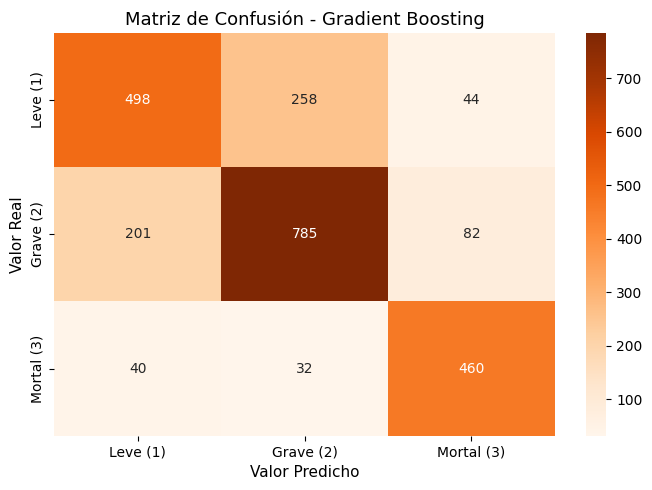

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_gb)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Leve (1)', 'Grave (2)', 'Mortal (3)'],
            yticklabels=['Leve (1)', 'Grave (2)', 'Mortal (3)'])
plt.title('Matriz de Confusión - Gradient Boosting', fontsize=13)
plt.ylabel('Valor Real', fontsize=11)
plt.xlabel('Valor Predicho', fontsize=11)
plt.tight_layout()
plt.savefig('mc_gradient_boosting.png', dpi=300, bbox_inches='tight')
plt.show()

In [10]:
import joblib
joblib.dump(gb_model, '../models/gb_model.pkl')

['../models/gb_model.pkl']